# Static Plotting Examples

This notebook demonstrates the usage of `adataviz` static plotting functions:
- `plot_categorical` – UMAP colored by categorical annotations
- `plot_gene` – UMAP colored by gene expression + violin plot
- `stacked_barplot` – cell type composition across groups

In [1]:
import os
import sys
# sys.path.append(os.path.expanduser("~/Projects/Github/adataviz"))
import adataviz as av
import anndata

In [2]:
# Path to the example AnnData file
adata_path = (
    "/home/x-wding2/Projects/BICAN/adata/HMBA_v2/HMBA.Group.downsample_1500.h5ad"
)

# Quick look at the data
adata = anndata.read_h5ad(adata_path, backed="r")
print(f"Shape: {adata.shape}")
print(
    f"Categorical columns: Neighborhood ({adata.obs['Neighborhood'].nunique()}), "
    f"Class ({adata.obs['Class'].nunique()}), "
    f"Subclass ({adata.obs['Subclass'].nunique()}), "
    f"Group ({adata.obs['Group'].nunique()})"
)
print(f"Embeddings: {list(adata.obsm.keys())}")
adata.file.close()

Shape: (70134, 36601)
Categorical columns: Neighborhood (4), Class (12), Subclass (36), Group (60)
Embeddings: ['X_scVI', 'X_umap']


## 1. `plot_categorical` – Categorical UMAP (or TSNE)

Plot a UMAP embedding colored by a categorical variable (e.g. `Class`),
with labeled cluster centroids.

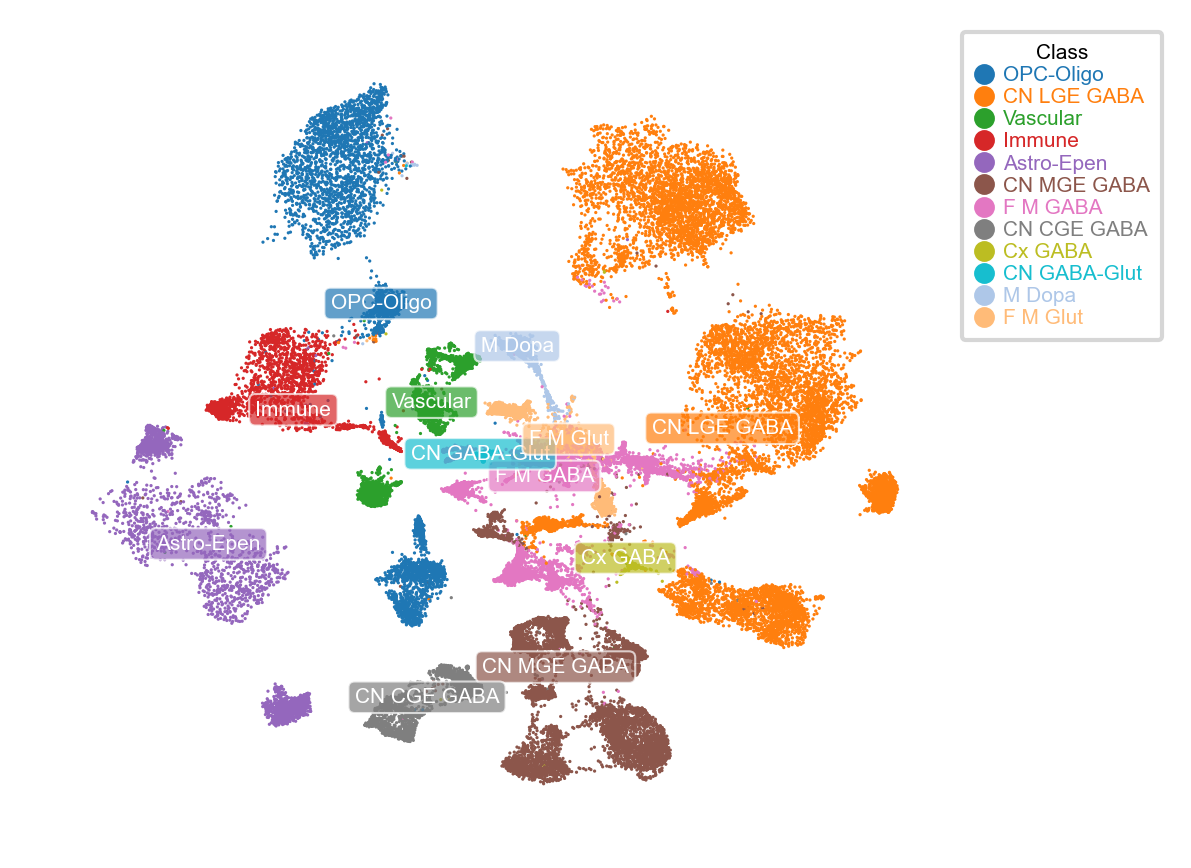

In [3]:
# Basic usage: color by Class with text annotation
av.pl.plot_categorical(
    adata=adata_path,
    basis="umap",
    groupby="Class",
    coding=False,
    text_anno="Class",
    # save="Class.umap.no_text.pdf",
    palette=None,  # legend_kws=dict(bbox_to_anchor=(0.1,0.9),ncol=2),
    axis_format="tiny",
    figsize=(4, 3.5),  # rectangle_marker=True
    show_legend=True,
)

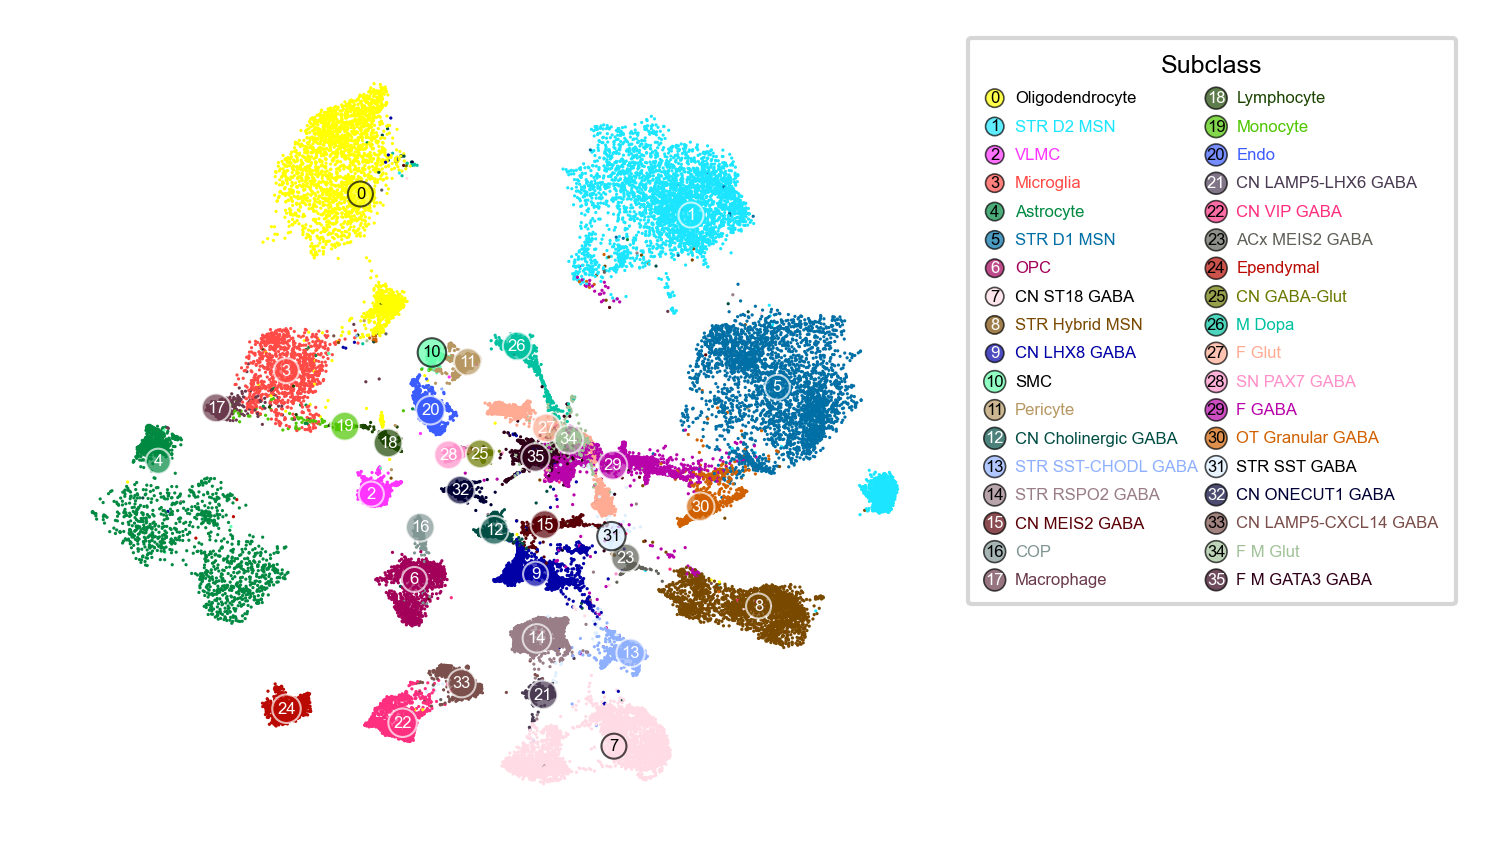

In [4]:
# Color by Subclass with more legend columns and coding annotation
av.pl.plot_categorical(
    adata=adata_path,
    basis="umap",
    groupby="Subclass",
    coding=True,
    text_anno="Subclass",
    # save="Subclass.umap.no_text.pdf",
    palette=None,
    fontsize=4,
    legend_fontsize=4,
    legend_title_fontsize=6,
    legend_kws=dict(
        ncol=2,  # bbox_to_anchor=(0.7,0.9)
        labelspacing=0.8,
        borderpad=1,
        handletextpad=0.8,
    ),
    axis_format=None,
    figsize=(4, 3.5),
    show_legend=True,
)

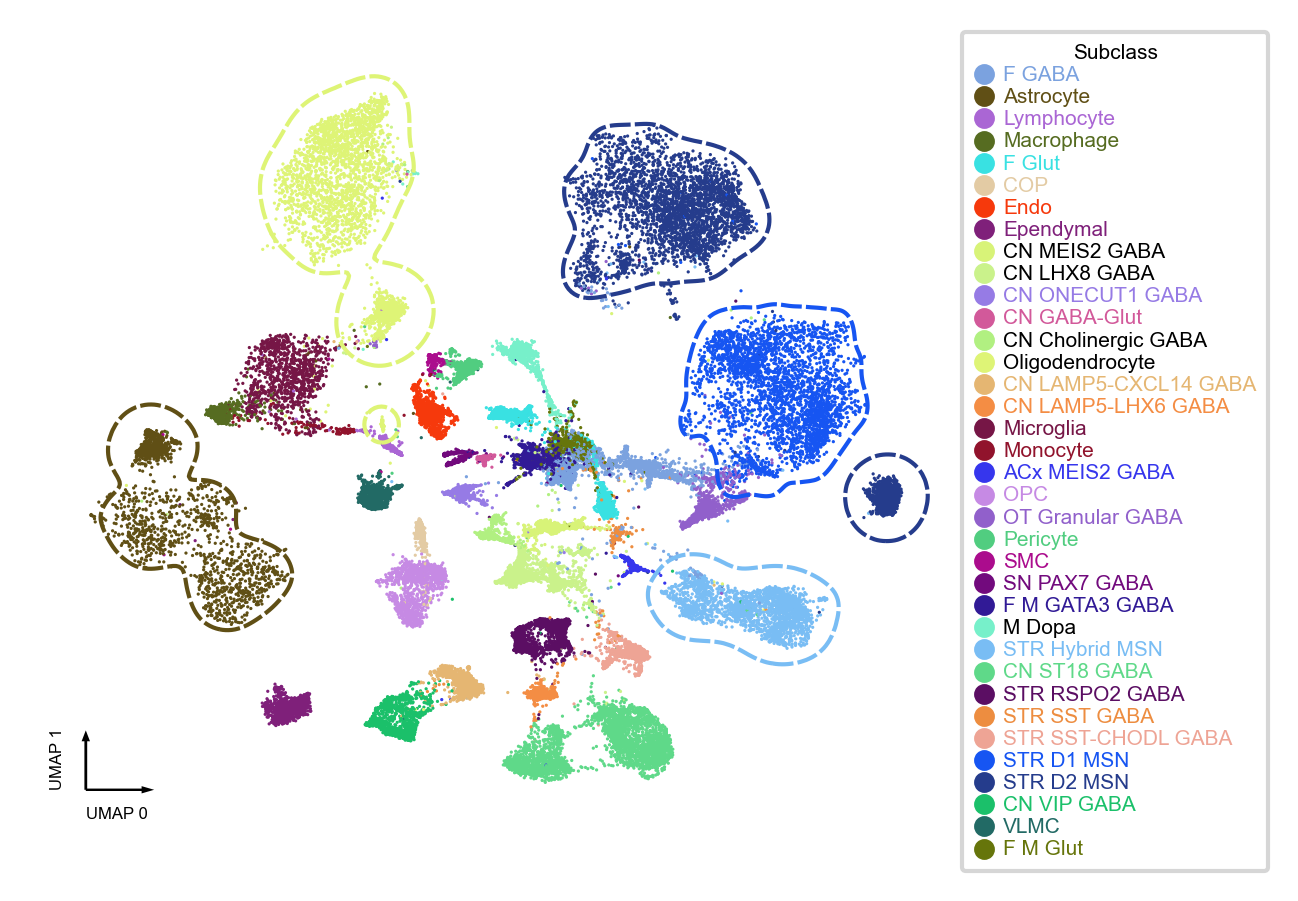

In [38]:
# Basic usage: color by Subclass with outline (for selected cell types only)
palette = (
    adata.obs.drop_duplicates("Subclass")
    .set_index("Subclass")["color_hex_subclass"]
    .to_dict()
)
av.pl.plot_categorical(
    adata=adata_path,
    basis="umap",
    groupby="Subclass",
    coding=False,
    text_anno=None,
    outline=adata.obs.Subclass.apply(
        lambda x: x
        if x
        in [
            "STR D1 MSN",
            "STR D2 MSN",
            "STR Hybrid MSN",
            "Astrocyte",
            "Oligodendrocyte",
        ]
        else None
    ),
    outline_kws={
        "linewidth": 1,
        "palette": palette,
        "linestyles": "densely dashed",
        "single_contour_pad": 1,
        "threshold": 0.04,
        "smooth_sigma": 5,
    },
    palette=palette,  # legend_kws=dict(bbox_to_anchor=(0.1,0.9),ncol=2),
    axis_format="tiny",
    figsize=(4, 3.5),  # rectangle_marker=True
    show_legend=True,
)

## 2. `plot_gene` – Gene Expression on UMAP + Violin Plot

Plot a single gene's expression on the UMAP embedding.
When `groupby` is provided, a violin plot is also generated.

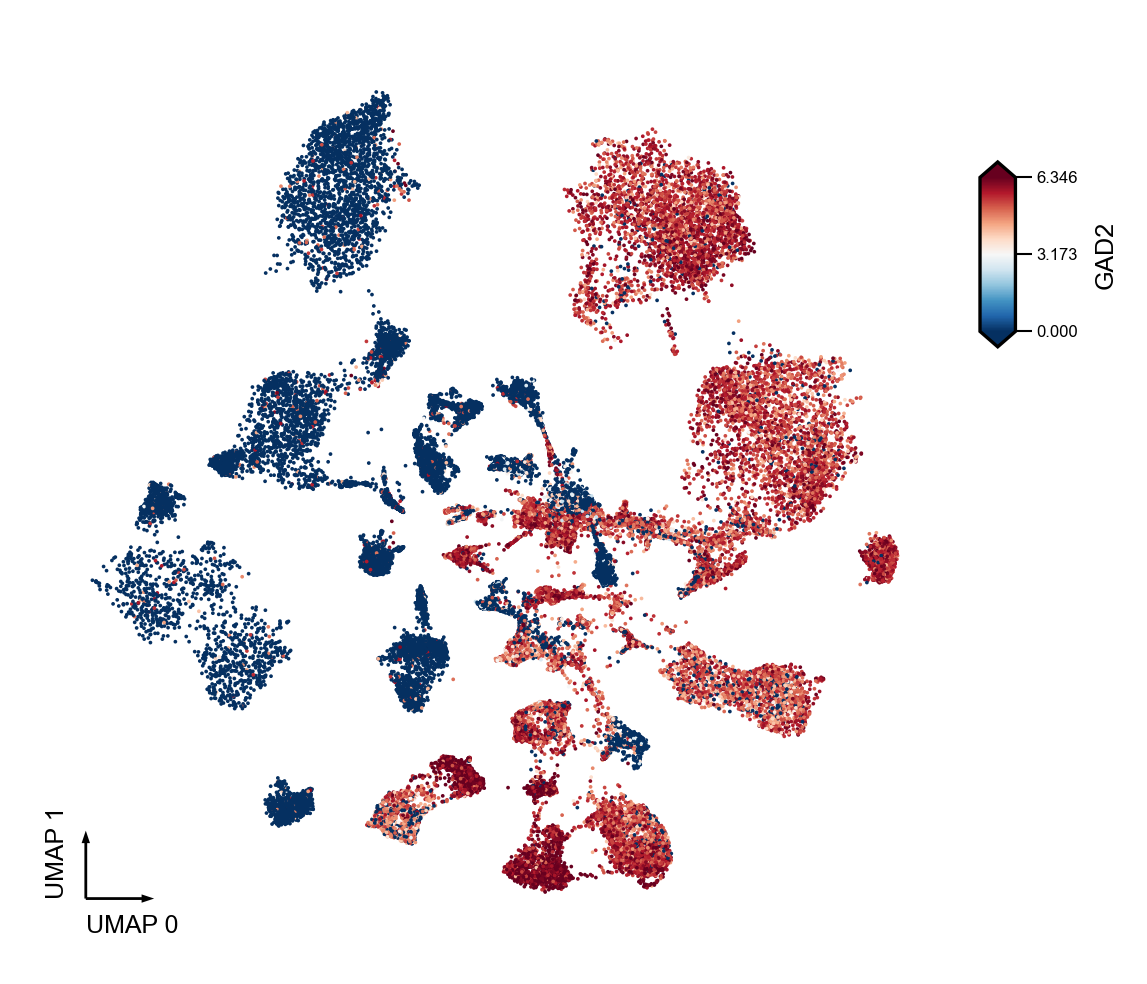

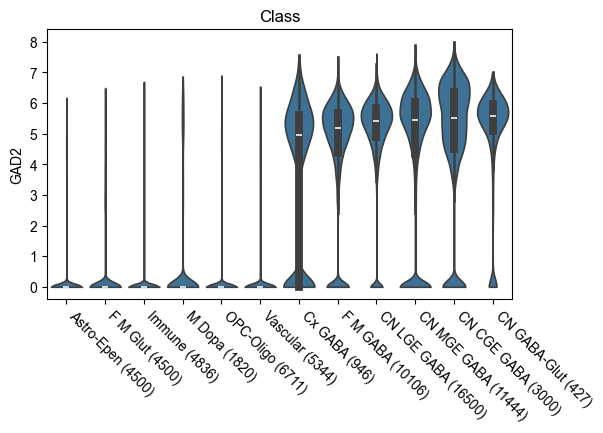

In [7]:
# Plot GAD2 (GABAergic neuron marker) colored on UMAP, with violin by Class
av.pl.plot_gene(
    adata=adata_path,
    gene="GAD2",
    groupby="Class",
    basis="umap",
    cmap="RdBu_r",
    prefix="GAD2_example",
)

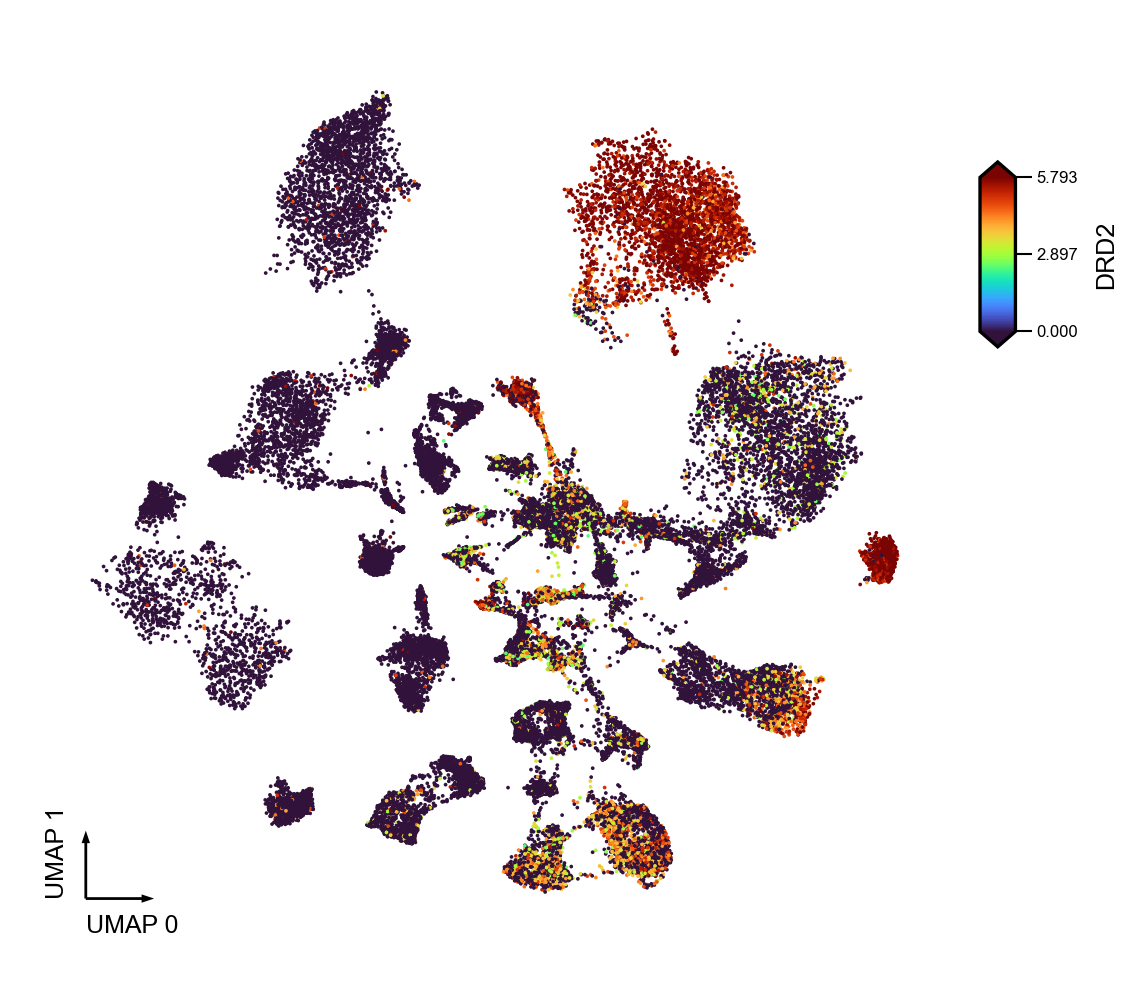

In [8]:
# Plot SLC17A7 (glutamatergic marker) without groupby (UMAP only)
av.pl.plot_gene(
    adata=adata_path,
    gene="DRD2",
    basis="umap",
    cmap="turbo",
    prefix="DRD2_example",
)

## 3. `stacked_barplot` – Cell Type Composition

Show the proportion of cell types (e.g. `Class`) within each anatomical region or donor.

In [9]:
# Load obs for barplot/pieplot (these accept a DataFrame directly)
adata = anndata.read_h5ad(adata_path, backed="r")
obs = adata.obs.copy()
adata.file.close()

# Build color palettes from the existing color columns in obs
color_palettes = {}
for level in ["neighborhood", "class", "subclass", "group"]:
    col_name = level.capitalize() if level != "neighborhood" else "Neighborhood"
    hex_col = f"color_hex_{level}"
    if hex_col in obs.columns:
        color_palettes[col_name] = (
            obs.drop_duplicates(col_name).set_index(col_name)[hex_col].to_dict()
        )

print("Available color palettes:", list(color_palettes.keys()))

Available color palettes: ['Neighborhood', 'Class', 'Subclass', 'Group']


<Figure size 640x480 with 0 Axes>

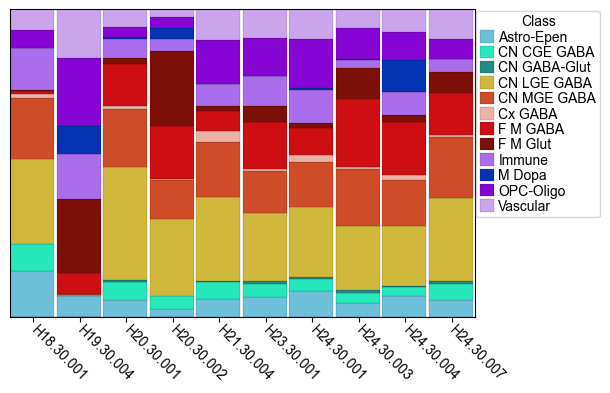

<Axes: xlabel='donor_id'>

In [10]:
# Stacked barplot: Class composition per donor
av.pl.stacked_barplot(
    obs=obs,
    groupby="donor_id",
    column="Class",
    palette=color_palettes.get("Class"),
    width=6,
    height=4,
)

<Figure size 640x480 with 0 Axes>

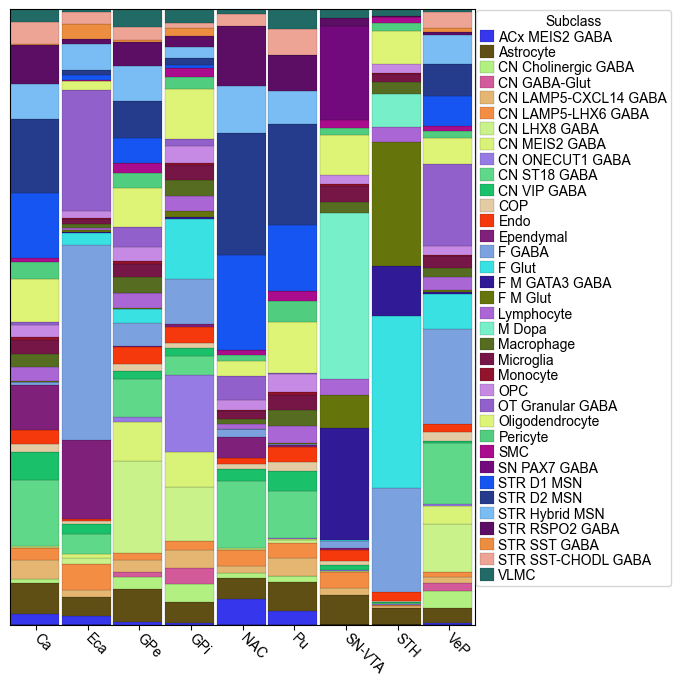

In [11]:
# Stacked barplot: Subclass composition per Neighborhood
ax = av.pl.stacked_barplot(
    obs=obs,
    groupby="anatomical_region_merged",
    column="Subclass",
    palette=color_palettes.get("Subclass"),
    width=6,
    height=8,
)

In [12]:
keep_genes = [
    "GAD2",
    "LMX1A",
    "NTNG1",
    "PCDH19",
    "PTPRE",
    "RASGRF1",
    "CAPN5",
    "VCAN",
    "FHOD3",
    "LRFN2",
    "GRIK4",
    "NRG3",
    "EBF3",
    "SOX6",
    "RGS6",
    "KCND3",
    "ST3GAL1",
    "SV2C",
    "GPR26",
    "NTN1",
    "RIMS1",
    "PEX5L",
    "IL1RAP",
    "SDC1",
    "ROBO2",
    "GALNTL6",
    "B3GALT1",
    "DCC",
    "CALB1",
    "VWA5B1",
    "CDH2",
    "NIN",
    "ALCAM",
    "ZFHX3",
    "NRP2",
    "ST8SIA2",
    "TMTC1",
]
cell_type_order = ["SN-VTR GAD2 Dopa", "SN SOX6 Dopa", "SN-VTR CALB1 Dopa"]

(1820, 27)
Using expression cutoff: 0.0
Starting..
Calculating row orders..
Reordering rows..
Calculating col orders..
Reordering cols..
Plotting matrix..
Inferred max_s (max size of scatter point) is: 122.7945351640952
Plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 12.172222222222222 mm


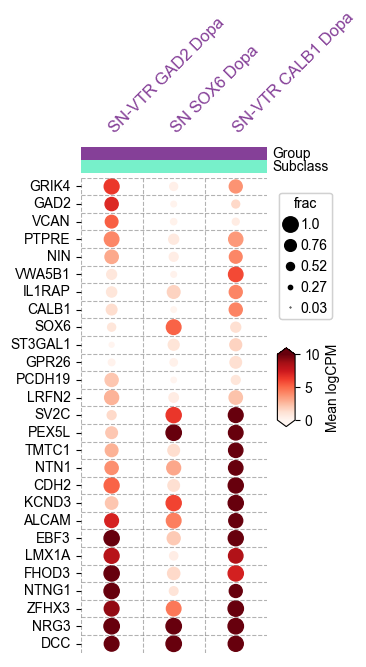

In [13]:
keep_genes = [
    "GAD2",
    "LMX1A",
    "NTNG1",
    "PCDH19",
    "PTPRE",
    "VCAN",
    "FHOD3",
    "LRFN2",
    "GRIK4",
    "NRG3",
    "EBF3",
    "SOX6",
    "KCND3",
    "ST3GAL1",
    "SV2C",
    "GPR26",
    "NTN1",
    "PEX5L",
    "IL1RAP",
    "DCC",
    "CALB1",
    "VWA5B1",
    "CDH2",
    "NIN",
    "ALCAM",
    "ZFHX3",
    "TMTC1",
]
cm1 = av.pl.plot_genes(
    adata=adata_path,
    query_str="Subclass=='M Dopa'",
    obs=None,
    groupby="Group",
    parent_col="Subclass",
    modality="RNA",  # mc or RNA
    use_raw=True,  # True for RNA
    expression_cutoff="p5",  # for RNA, could be int, median, mean of p5, p95 and so on
    genes=keep_genes,
    cell_type_order=cell_type_order,
    gene_order=keep_genes,
    row_cluster=True,
    col_cluster=False,
    cmap="Reds",
    group_legend=False,
    parent_legend=False,
    title="M_Dopa RNA",
    palette="/home/x-wding2/Projects/BICAN/adata/HMBA_v2/HMBA_color_palette.xlsx",
    legend_kws=dict(extendfrac=0.1, extend="both", label="Mean logCPM"),
    normalize_per_cell=False,
    clip_norm_value=10,
    hypo_score=False,
    figsize=(2.5, 6),
    marker="o",
    plot_kws=dict(
        vmin=0,
        vmax=10,
        xticklabels_kws={
            "labelrotation": -30,
            "labelcolor": "black",
            "labelsize": 12,
            "bottom": True,
        },
        yticklabels_kws=dict(left=True),
    ),
    outname="M_Dopa.RNA.pdf",
)

In [14]:
keep_genes = [
    # MEDIUM SPINY NEURONS (MSN) - High Confidence
    "MEIS2",
    "BCL11B",
    "PPP1R1B",
    "GNG7",
    "ADCY5",  #'EGR1','MEIS1',
    "CHRM1",
    "CHRM4",
    "GRM4",
    "KCNJ4",
    "GAD2",
    "GAD1",
    "ARPP21",
    "FOSL2",
    "RFX3",
    "FOXO3",
    "PDE10A",  #'SLC4A4','PHACTR1',  # MSN Signaling, 'NPAS2'
    "FOXP1",
    "FOXO1",
    "DRD1",  # D1-MSN (Direct Pathway)
    "DRD2",
    "ADORA2A",
    "OPRD1",  # D2-MSN (Indirect Pathway):
    # M Dopa
    "NR4A2",
    "PBX1",
    "SLC6A3",
    "TH",
    "EBF3",
    "SLC18A2",
    "LMX1A",
    "LMX1B",
    "PITX3",
    "RET",
    "KCNJ6",  #'NFIA',
    # CHOLINERGIC INTERNEURONS (ChI) - High Confidence
    "SLC18A3",
    "GRK5",
    "CHAT",
    "SLC5A7",
    "LHX6",
    "LHX8",
    "GDNF",  # 'TLE3', 'ARX', 'INPP4B','NTRK1',
    # 'ACHE', acetylcholine (ACh), degradation of acetylcholine (ACh) happen largely extracellular
]

cell_type_order = [
    "STR D1 MSN",
    "STR D2 MSN",
    "STR Hybrid MSN",
    "M Dopa",
    "CN Cholinergic GABA",
]
gene_order = keep_genes

Normalizing cell level fraction by alpha and beta (prior_mean)
(145394, 40)
Starting..
Calculating row orders..
Reordering rows..
Calculating col orders..
Reordering cols..
Plotting matrix..
Inferred max_s (max size of scatter point) is: 87.47432584626135
Plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 46.56805555555555 mm


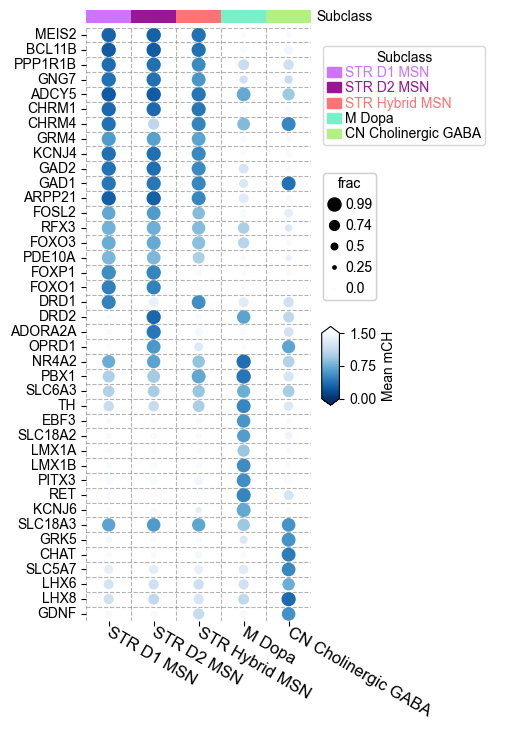

In [16]:
cm1 = av.pl.plot_genes(
    adata="/home/x-wding2/Projects/BG/adata/BG.gene-CHN.h5ad",
    query_str=None,
    obs="~/Projects/BG/clustering/100kb/obs.Dopa-ChI-MSN.tsv",
    groupby="Subclass",
    parent_col=None,
    modality="mc",  # mc or RNA
    use_raw=False,  # True for RNA
    expression_cutoff="p5",  # for RNA, could be int, median, mean of p5, p95 and so on
    genes=keep_genes,
    cell_type_order=cell_type_order,
    gene_order=gene_order,
    row_cluster=False,
    col_cluster=False,
    cmap="Blues_r",
    group_legend=True,
    parent_legend=True,
    title="mCH",
    palette="/home/x-wding2/Projects/BG/metadata/BG_color_palette.xlsx",
    legend_kws=dict(extendfrac=0.1, extend="both", label="Mean mCH"),
    normalize_per_cell=True,
    clip_norm_value=10,
    hypo_score=False,
    figsize=(3, 7),
    marker="o",
    plot_kws=dict(
        vmin=0,
        vmax=1.5,
        yticklabels_kws=dict(left=True),
        xticklabels_kws=dict(
            labelrotation=-30, labelcolor="black", labelsize=12, bottom=True
        ),
    ),
    outname="Dopa-ChI-MSN.mCH.pdf",
)